Chargement du modèle: C:\Users\MSI\Desktop\COVID19-XRay-Classification\models\simple_cnn_model.h5


Found 8464 images belonging to 4 classes.
Validation set: 8464 images
Classes: {'COVID': 0, 'Lung_Opacity': 1, 'NORMAL': 2, 'Viral Pneumonia': 3}


C:\Users\MSI\anaconda3\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


265/265 ━━━━━━━━━━━━━━━━━━━━ 55s 207ms/step

RAPPORT DE CLASSIFICATION DÉTAILLÉ
                 precision    recall  f1-score   support

          COVID      0.856     0.775     0.813      1446
   Lung_Opacity      0.803     0.864     0.832      2404
         NORMAL      0.890     0.881     0.886      4076
Viral Pneumonia      0.900     0.885     0.892       538

       accuracy                          0.859      8464
      macro avg      0.862     0.851     0.856      8464
   weighted avg      0.860     0.859     0.859      8464



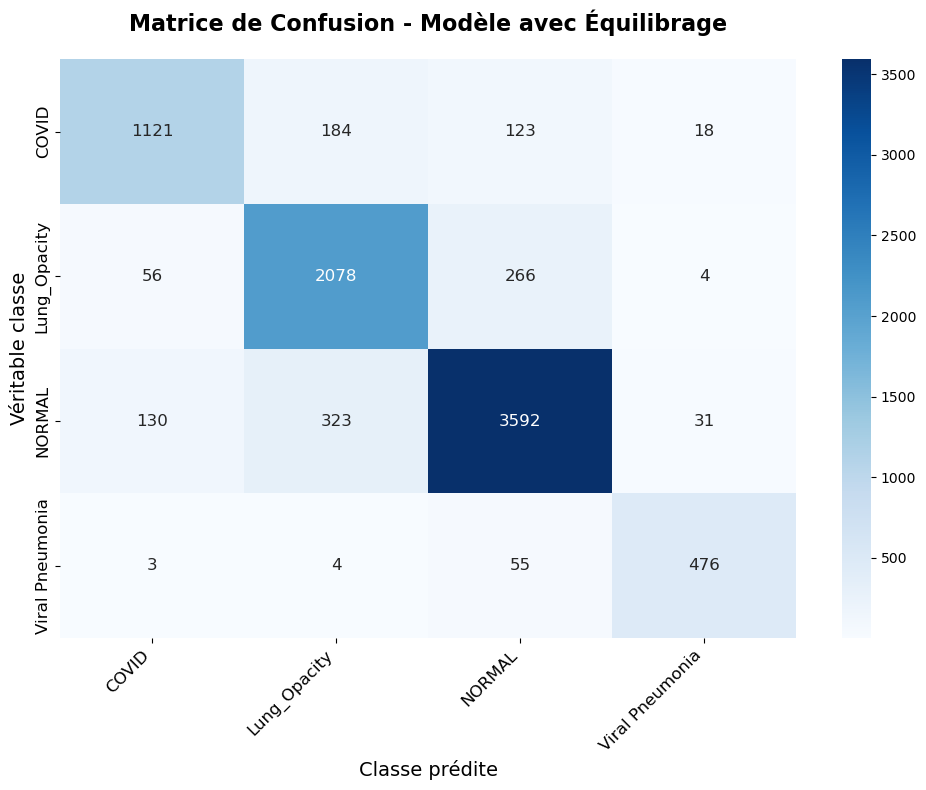


ANALYSE DÉTAILLÉE PAR CLASSE

COVID:
  Accuracy: 0.775 (1121/1446)
  Erreurs: {'Lung_Opacity': 184, 'NORMAL': 123, 'Viral Pneumonia': 18}

Lung_Opacity:
  Accuracy: 0.864 (2078/2404)
  Erreurs: {'COVID': 56, 'NORMAL': 266, 'Viral Pneumonia': 4}

NORMAL:
  Accuracy: 0.881 (3592/4076)
  Erreurs: {'COVID': 130, 'Lung_Opacity': 323, 'Viral Pneumonia': 31}

Viral Pneumonia:
  Accuracy: 0.885 (476/538)
  Erreurs: {'COVID': 3, 'Lung_Opacity': 4, 'NORMAL': 55}


In [2]:
# 04_evaluation_gradcam.ipynb - Version avec le nouveau modèle
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import os
import seaborn as sns

# Chemins
data_dir = r"C:\Users\MSI\Desktop\COVID19-XRay-Classification\data"
model_path = r"C:\Users\MSI\Desktop\COVID19-XRay-Classification\models\simple_cnn_model.h5"
# Charger le modèle amélioré
print(f"Chargement du modèle: {model_path}")
model = load_model(model_path)

# Recréer le générateur (mêmes paramètres que l'entraînement)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
val_gen = val_datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"Validation set: {val_gen.samples} images")
print(f"Classes: {val_gen.class_indices}")

# Prédictions
val_gen.reset()
y_pred = model.predict(val_gen, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_gen.classes

# Rapport détaillé
print("\n" + "="*60)
print("RAPPORT DE CLASSIFICATION DÉTAILLÉ")
print("="*60)

class_names = list(val_gen.class_indices.keys())
report = classification_report(y_true, y_pred_classes, 
                              target_names=class_names,
                              digits=3,
                              output_dict=False,
                              zero_division=0)

print(report)

# Matrice de confusion améliorée
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12})

plt.title('Matrice de Confusion - Modèle avec Équilibrage', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Véritable classe', fontsize=14)
plt.xlabel('Classe prédite', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# Analyse par classe
print("\n" + "="*60)
print("ANALYSE DÉTAILLÉE PAR CLASSE")
print("="*60)

for i, class_name in enumerate(class_names):
    # Indices pour cette classe
    class_indices = np.where(y_true == i)[0]
    
    if len(class_indices) > 0:
        # Prédictions pour cette classe
        class_preds = y_pred_classes[class_indices]
        class_correct = np.sum(class_preds == i)
        class_accuracy = class_correct / len(class_indices)
        
        # Distribution des erreurs
        error_distribution = {}
        for wrong_class in np.unique(class_preds[class_preds != i]):
            error_distribution[class_names[wrong_class]] = np.sum(class_preds == wrong_class)
        
        print(f"\n{class_name}:")
        print(f"  Accuracy: {class_accuracy:.3f} ({class_correct}/{len(class_indices)})")
        if error_distribution:
            print(f"  Erreurs: {error_distribution}")